In [1]:
import os
seed_index=527
folder_path = "/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/"+str(seed_index)
if not os.path.exists(folder_path):  #判断是否存在文件夹如果不存在则创建为文件夹
    os.makedirs(folder_path)
f=folder_path+"/"

In [2]:
import numpy as np
import torch
# x=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/yc_21.npy')
# y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
# y2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")
###############################
# et=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/et_21.npy")
# nan_idx=np.load('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/conv3d_res/nan_idx.npy')
# et=np.delete(et,nan_idx,axis=0)
##########################################################################
# x=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc.npy")
# y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
# y2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/y2c_input.npy")
######################################################################
x=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/xc_21.npy")
# y=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/smc_somo.npy')[:,:,-1]
y2=np.load("/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/input/y2c_21.npy")

In [3]:
y2.shape,y2.min(),y2.max(),x.shape,x.min()

((737, 1, 216, 21, 21), 0.0, 1.0, (737, 216, 21, 21, 10), nan)

In [4]:
# nanindex=np.where(np.isnan(y[:,205]))
# x=np.delete(x,nanindex,axis=0)
# y=np.delete(y,nanindex,axis=0)
# y2=np.delete(y2,nanindex,axis=0)

In [5]:
xn=np.full((x.shape[0],216,21,21,9),np.nan)
for i in range(8):
    xmin=np.nanmin(x[:,:,:,:,i])
    xmax=np.nanmax(x[:,:,:,:,i])
    xn[:,:,:,:,i]=(x[:,:,:,:,i]-xmin)/(xmax-xmin)
xn=np.nan_to_num(xn,nan=0)

ymin=np.nanmin(y)
ymax=np.nanmax(y)
yn=(y-ymin)/(ymax-ymin)
y2min=np.nanmin(y2)
y2max=np.nanmax(y2)
y2n=(y2-y2min)/(y2max-y2min)
y2n=np.nan_to_num(y2n,nan=0)
print("y1max",ymax,"y1min",ymin)


#####################
xn[:,:,:,:,8]=y2n[:,0,:,:,:]
print(xn.shape)

y1max 0.2323722156863067 y1min -0.20549230420163983
(737, 216, 21, 21, 9)


In [6]:
len_data=x.shape[0]
shuffled_indices = np.random.permutation(len_data)

train_idx = shuffled_indices[:int(0.7*len_data)]
val_idx = shuffled_indices[int(0.7*len_data):int(0.8*len_data)]
test_idx=shuffled_indices[int(0.8*len_data):]

x=np.transpose(xn,(0,4,1,2,3))
y=np.expand_dims(yn,axis=-1)
y=y[:,6:,:]


x_train=x[train_idx,:,:,:,:]
y_train=y[train_idx,:,:]
x_val=x[val_idx,:,:,:,:]
y_val=y[val_idx,:,:]
x_test=x[test_idx,:,:,:,:]
y_test=y[test_idx,:,:]



print(x_train.shape,y_train.shape,x_val.shape)
print(x.min(),x.max(),y.min(),y.max(),)#make sure they are all maxmin

(515, 9, 216, 21, 21) (515, 210, 1) (74, 9, 216, 21, 21)
0.0 1.0 0.0 1.0


In [7]:
# x=np.transpose(xn,(0,4,1,2,3))
# y=np.expand_dims(yn,axis=-1)
# y=y[:,6:,:]
x.shape,y.shape

((737, 9, 216, 21, 21), (737, 210, 1))

In [8]:
y2_max=1;y2_min=0
# y1_max=0.2324; y1_min=-0.2055 
y1_max=ymax; y1_min=ymin

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader,TensorDataset
from torch.nn import Conv1d,Conv2d,Conv3d,Flatten,Linear
from torch.nn import MaxPool1d,MaxPool2d,MaxPool3d
from torch.nn.functional import relu
from torch.optim import SGD,Adam
from torch.nn import L1Loss
# from ignite.metrics import SSIM
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import OrderedDict
from torch import nn, optim
from torchmetrics.functional import r2_score
import torch.optim as optim
import torch.distributed as dist
import torch.multiprocessing as mp
import numpy as np
from torch.nn import init
import random
import os
#define the initial function to init the layer's parameters for the network
def weigth_init(m):
    if isinstance(m, nn.Conv2d):
        init.xavier_uniform_(m.weight.data)
        init.constant_(m.bias.data,0.1)
    elif isinstance(m, nn.BatchNorm2d):
        m.weight.data.fill_(1)
        m.bias.data.zero_()
    elif isinstance(m, nn.Linear):
        m.weight.data.normal_(0,0.01)
        m.bias.data.zero_()

def seed_torch(seed=1029):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed) # 为了禁止hash随机化，使得实验可复现
	np.random.seed(seed)
	torch.manual_seed(seed)
	torch.cuda.manual_seed(seed)
	torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.
	torch.backends.cudnn.benchmark = False
	torch.backends.cudnn.deterministic = True

In [10]:
class CustomDataset(Dataset):
    def __init__(self, x, y1):
        self.x = torch.tensor(x, dtype=torch.float32)  # Convert to PyTorch tensor
        self.y1 = torch.tensor(y1, dtype=torch.float32)
        
    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y1[idx]


class RegressionModel3(torch.nn.Module):
    def __init__(self):
        super(RegressionModel3, self).__init__()

        self.c0 = nn.Conv3d(in_channels=9, out_channels=128, kernel_size=(3,3,3), padding=(0,1,1), stride=1)
        self.c1 = nn.Conv3d(in_channels=128, out_channels=512, kernel_size=(3,3,3), padding=(0,1,1), stride=1)
        self.c2 = nn.Conv3d(in_channels=512, out_channels=1024, kernel_size=(3,3,3), padding=(0,1,1), stride=1)
        self.c3 = nn.Conv3d(in_channels=1024, out_channels=1, kernel_size=(1,3,3),padding=(0,1,1),stride=1)
        self.l1=nn.Linear(441, 484)
        self.l2=nn.Linear(484, 968)
        self.l3=nn.Linear(968, 1)
        self.dropout=nn.Dropout(p=0.1)
        self.max_pooling_layer3d=MaxPool3d(1)
        self.leakyrelu=nn.LeakyReLU(0.1)
        self.relu=nn.ReLU()

        self.conv_am=nn.Conv3d(in_channels=2,out_channels=1,kernel_size=(1,3,3),stride=1,padding=(0,1,1),bias=False)
        self.sg=nn.Sigmoid()
        self.bn0=nn.BatchNorm3d(128)
        self.bn1=nn.BatchNorm3d(512)
        self.bn2=nn.BatchNorm3d(1024)
        self.bn3=nn.BatchNorm3d(1024)
        
    
    def forward(self, x):
        # print("x1",x.shape)
        x = self.leakyrelu(self.c0(x))
        x=self.dropout(x)
        x=self.max_pooling_layer3d(x)
        x=self.bn0(x)
        
        # print("x2",x.shape)
        x = self.leakyrelu(self.c1(x))
        x=self.dropout(x)
        x=self.max_pooling_layer3d(x)
        x=self.bn1(x)
       
        
        x = self.leakyrelu(self.c2(x))
        x=self.dropout(x)
        x=self.max_pooling_layer3d(x)
        x=self.bn2(x)

               
        x=self.max_pooling_layer3d(x)
        x=self.leakyrelu(self.c3(x))
        x=self.dropout(x)
        x=self.max_pooling_layer3d(x)
       
        x=x.squeeze(dim=1)
        x=torch.flatten(x,start_dim=2)
        x=self.leakyrelu(self.l1(x))
        x=self.dropout(x)
        x=self.leakyrelu(self.l2(x))
        x=self.dropout(x)
        y1=self.leakyrelu(self.l3(x))

        return y1

In [11]:
batch_size =4
train_dataloader = DataLoader(CustomDataset(x_train, y_train), batch_size=batch_size, shuffle=False)
val_dataloader = DataLoader(CustomDataset(x_val, y_val), batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(CustomDataset(x_test, y_test), batch_size=batch_size, shuffle=False)
xy_dataloader = DataLoader(CustomDataset(x, y), batch_size=batch_size, shuffle=False)

torch.save(test_dataloader, f+"test_dataloader.pth")
torch.save(val_dataloader, f+"val_dataloader.pth")
torch.save(train_dataloader, f+"train_dataloader.pth")
torch.save(xy_dataloader, f+"xy_dataloader.pth")

In [12]:


seed_torch(seed_index)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RegressionModel3()
if torch.cuda.device_count() > 1:
     print("Let's use", torch.cuda.device_count(), "GPUs!")
     model = torch.nn.DataParallel(model).to(device)#,device_ids=[0,1, 2, 3, 4, 5, 6, 7]
model.to(device)
model.apply(weigth_init)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training loop
n_epochs = 500
train_loss_list=[]
val_loss_list=[]
train_loss_1=[]
val_loss_1=[]

for epoch in range(n_epochs):
    for batch_x, batch_y in train_dataloader:  # Iterate over batches
        optimizer.zero_grad()

        batch_x=batch_x.to(device)
        batch_y=((batch_y)*(y1_max-y1_min)+y1_min).to(device)
        y1_pred= model(batch_x)
        y1_pred=((y1_pred)*(y1_max-y1_min)+y1_min).to(device)
        loss1 = loss_fn(y1_pred, batch_y)
    

        print(f"****:{epoch}:{y1_pred.mean().item()-batch_y.mean().item():.6f}",loss1.item())
        loss=loss1
        train_loss_1.append(loss1.item())
      
        loss.mean().backward()
        # loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Clip gradients
        optimizer.step()

    # Validation (compute validation loss)
    with torch.no_grad():
        val_loss = 0
        for val_batch_x, val_batch_y in val_dataloader:
            val_batch_x=val_batch_x.to(device)
            val_batch_y=((val_batch_y)*(y1_max-y1_min)+y1_min).to(device)
            y1_val_pred= model(val_batch_x.cuda())  
            y1_val_pred=((y1_val_pred)*(y1_max-y1_min)+y1_min).to(device)
            val_loss1 = loss_fn(y1_val_pred, val_batch_y)
            val_loss += val_loss1
            val_loss_1.append(loss1.item())
            print(f"====:{epoch}:{y1_val_pred.mean().item()-val_batch_y.mean().item():.6f}",val_loss1.item())

        val_loss /= len(val_dataloader)

    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {loss.item():.6f} - Val Loss: {val_loss.item():.6f}")
    train_loss_list.append(loss.item())
    val_loss_list.append(val_loss.item())


np.save(f+"train_loss.npy",np.array(train_loss_list))
np.save(f+"val_loss.npy",np.array(val_loss_list))
np.save(f+"train_loss_y1.npy",np.array(train_loss_1))
np.save(f+"val_loss_y1.npy",np.array(val_loss_1))

Let's use 8 GPUs!


/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/torch/nn/modules/conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv3d(


****:0:-0.205816 0.043433208018541336
****:0:0.458419 0.2129267156124115
****:0:-0.024163 0.0032735366839915514
****:0:-0.137400 0.022588931024074554
****:0:0.032865 0.014542479999363422
****:0:-0.042872 0.007032935041934252
****:0:-0.065707 0.007270992733538151
****:0:-0.067629 0.008610752411186695
****:0:0.154476 0.02706487476825714
****:0:0.002809 0.000613940239418298
****:0:-0.115414 0.013652997091412544
****:0:-0.076969 0.006854713894426823
****:0:0.057237 0.004924947861582041
****:0:0.039120 0.003976752981543541
****:0:-0.003328 0.0023878864012658596
****:0:-0.041659 0.0029232872184365988
****:0:-0.086969 0.0087868208065629
****:0:-0.010267 0.0017569101182743907
****:0:0.035964 0.0028930704575031996
****:0:0.039939 0.0029141143895685673
****:0:0.038072 0.004085616208612919
****:0:-0.053067 0.004198216367512941
****:0:-0.090394 0.009014949202537537
****:0:-0.060541 0.004565237555652857
****:0:0.005778 0.0010865508811548352
****:0:0.039213 0.004619539715349674
****:0:0.054838 0.004

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


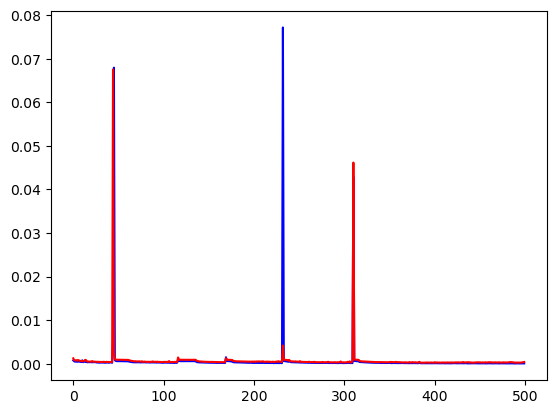

In [13]:
train_loss_list=np.load(f+"train_loss.npy")
val_loss_list=np.load(f+"val_loss.npy")
plt.plot(train_loss_list,c="blue")
plt.plot(val_loss_list,c="red")

In [14]:


# test_dataloader=torch.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv5-utb/xy_dataloader.pth")

y_test_pred_list=[]
y_test_obs_list=[]



for test_batch_x, test_batch_y in test_dataloader:
    with torch.no_grad():
        test_batch_x=test_batch_x.to(device)
        test_batch_y=(test_batch_y*(y1_max-y1_min)+y1_min).to(device)
        y_test_pred = model(test_batch_x)
        y1_test_pred=((y_test_pred)*(y1_max-y1_min)+y1_min)
        y_test_pred_list.append(y1_test_pred)
        y_test_obs_list.append(test_batch_y)



y_test_pred_np=torch.cat(y_test_pred_list)
y_test_obs_np=torch.cat(y_test_obs_list)


from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
y_pred=y_test_pred_np.cpu().detach().numpy()
y_obs= y_test_obs_np.cpu().detach().numpy()
r1=r2_score(y_obs.reshape(-1,1),y_pred.reshape(-1,1))
mse=mean_squared_error(y_obs.reshape(-1,1),y_pred.reshape(-1,1))
np.save(f+"y_pred.npy",y_test_pred_np.cpu().detach().numpy())
np.save(f+"y_obs.npy",y_test_obs_np.cpu().detach().numpy())
print("y1:",r1,mse)

/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/torch/nn/modules/conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv3d(


y1: 0.7769185900688171 0.00020729419


In [15]:
y_xy_pred_list=[]
y_xy_obs_list=[]


for xy_batch_x, xy_batch_y in xy_dataloader:
    with torch.no_grad():
        # print(xy_batch_x.shape,xy_batch_y.shape) 

        xy_batch_x=xy_batch_x.to(device)
        xy_batch_y=(xy_batch_y*(y1_max-y1_min)+y1_min).to(device)
        y_xy_pred= model(xy_batch_x)
        y1_xy_pred=((y_xy_pred)*(y1_max-y1_min)+y1_min)
        y_xy_pred_list.append(y1_xy_pred)
        y_xy_obs_list.append(xy_batch_y)


 


y_xy_pred_np=torch.cat(y_xy_pred_list)
y_xy_obs_np=torch.cat(y_xy_obs_list)


from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
y_pred=y_xy_pred_np.cpu().detach().numpy()
y_obs= y_xy_obs_np.cpu().detach().numpy()
r1=r2_score(y_obs.reshape(-1,1),y_pred.reshape(-1,1))
mse=mean_squared_error(y_obs.reshape(-1,1),y_pred.reshape(-1,1))
np.save(f+"y_xy_pred.npy",y_xy_pred_np.cpu().detach().numpy())
np.save(f+"y_xy_obs.npy",y_xy_obs_np.cpu().detach().numpy())


print("y1:",r1,mse)

/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/torch/nn/modules/conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv3d(


y1: 0.812823474407196 0.00017069647


In [16]:
def integrated_gradient(model,input_data,n_iter,device):

    input_x = torch.from_numpy(input_data).float().to(device).type(torch.float16)
    baseline = torch.from_numpy(np.random.random(size=(input_x.shape))).float().to(device).type(torch.float16)*0
    attributions = []
    alpha = torch.from_numpy(np.linspace(0, 1, n_iter)).float().to(device)
    alpha = alpha.view(n_iter, *tuple(np.ones(baseline[0].ndim, dtype='int')))

    for k in range(input_x.shape[0]):#number of samples
        x_k = input_x[k].unsqueeze(0)
        base = baseline[k].unsqueeze(0)
        scaled_x = base + alpha * (x_k - base)
        attribution = torch.zeros(*scaled_x.shape)

        part_scaled_x = scaled_x
        part_scaled_x.requires_grad = True
        part_scaled_x=part_scaled_x.to(device)
        part_y_hat = model(part_scaled_x)
        # print(part_y_hat[0].shape,part_y_hat[1].shape)
        # a=torch.autograd.grad(part_y_hat, part_scaled_x)
        # print(a.shape)
        attribution[:,:,:,:,:]=torch.autograd.grad(part_y_hat[0], part_scaled_x, grad_outputs=torch.ones_like(part_y_hat[0]))[0]

        integrated = attribution.sum(axis=0) / n_iter
        integrated = integrated.to(device)

        ig = (x_k - base) * integrated
        ig = ig.detach().cpu().numpy().squeeze()
        attributions.append(ig)
    attributions = np.array(attributions)
    return attributions
def expected_gradients(model, data, baseline, n_iter, device):
    assert isinstance(data, np.ndarray),    "data should be np.ndarray type"
    assert data.ndim == 5, "(n_batch, n_feat, h, w)"
    assert isinstance(baseline, np.ndarray), "baseline should be np.ndarray type"
    assert baseline.ndim == 5, "(n_batch, n_feat, h, w)"

    input_x = torch.from_numpy(data).float().to(device)
    replace = 1#baseline.shape[0] < n_iter
    sample_idx = np.random.choice(baseline.shape[0], size=(input_x.shape[0], n_iter), replace=replace)
    print(sample_idx.shape)
    sampled_baseline = torch.from_numpy(baseline[sample_idx]).float().cuda()
    print(sampled_baseline.shape)

    alpha = np.linspace(0, 1, n_iter)
    alpha = torch.from_numpy(alpha).float().to(device)
    alpha = alpha.view(n_iter, *tuple(np.ones(baseline[0].ndim, dtype='int')))

    attributions = []
    for i in range(input_x.shape[0]):
        x = input_x[i].unsqueeze(0)
        ref = sampled_baseline[i]
        scaled_x = ref + alpha * (x - ref)
        attribution = torch.zeros(*scaled_x.shape).to(device)
        for i in range(n_iter):
            part_scaled_x = scaled_x[i:i+1]
            part_scaled_x.requires_grad = True
            part_y_hat = model(part_scaled_x)
            attribution[i] = torch.autograd.grad(part_y_hat[0], part_scaled_x, grad_outputs=torch.ones_like(part_y_hat[0]))[0]

        
        integrated = attribution.sum(axis=0) / n_iter
        ig = (x - ref).mean(axis=0) * integrated
        ig = ig.detach().cpu().numpy().squeeze()
        attributions.append(ig)
    attributions = np.array(attributions)

    return attributions     
xc=x
ael=[]
for i in [20,10]:
    ae=expected_gradients(model=model,data=xc,n_iter=i,baseline=xc,device=device)
    np.save(f+"eg_"+str(i)+".npy",ae)
    ael.append(ae)

(737, 20)
torch.Size([737, 20, 9, 216, 21, 21])
(737, 10)
torch.Size([737, 10, 9, 216, 21, 21])


In [17]:
torch.save(model,f+"model.pth")
model = torch.load(f+"model.pth").module
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

xc=x#np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc_input.npy")
ael=[]
for i in [10,20]:
    ae=expected_gradients(model=model,data=xc,n_iter=i,baseline=xc,device=device)
    np.save(f+"eg_"+str(i)+"_eval.npy",ae)
    ael.append(ae)

(737, 10)
torch.Size([737, 10, 9, 216, 21, 21])
(737, 20)
torch.Size([737, 20, 9, 216, 21, 21])


In [18]:

# xc=x#np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/xc_input.npy")
# ae=expected_gradients(model=model,data=xc,n_iter=10,baseline=xc,device=device)